# 03 · Feature engineering

Turns the cleaned line-level data into a model-ready matrix. All logic lives in `src/features.py` so the forecasting and supervised notebooks reuse it exactly.

**Feature families**
1. Targets — `Profit` (regression), `is_loss` (classification), `profit_margin`.
2. Date parts + cyclical (sin/cos) encodings of month & day-of-week.
3. Line-level — `price_per_unit`, `log_sales`, `is_discounted`, `discount_bucket`, `ship_days`.
4. Leakage-safe customer history — prior line count, prior sales sum/mean, prior loss rate, tenure.
5. RFM table + monthly series for downstream use.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_clean
from src import features as F
from src.plotting import set_style, savefig
from src.config import TABLE_DIR, PROCESSED_DIR

set_style()
df = load_clean()
df.shape

(9994, 24)

## 1 · Build the full feature frame

In [2]:
feat = F.build_feature_frame(df)
print('rows x cols:', feat.shape)
new_cols = [c for c in feat.columns if c not in df.columns]
print(f'{len(new_cols)} engineered columns:')
print(new_cols)

rows x cols: (9994, 50)
26 engineered columns:
['profit_margin', 'is_loss', 'order_year', 'order_month', 'order_quarter', 'order_week', 'order_dayofweek', 'order_dayofyear', 'order_is_weekend', 'order_is_month_end', 'order_is_quarter_end', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'price_per_unit', 'log_sales', 'is_discounted', 'discount_bucket', 'ship_days', 'cust_prior_lines', 'cust_prior_sales_sum', 'cust_prior_sales_mean', 'cust_prior_loss_rate', 'cust_days_since_first', 'cust_is_first_order']


In [3]:
feat[new_cols].head()

,profit_margin,is_loss,order_year,order_month,order_quarter,order_week,order_dayofweek,order_dayofyear,order_is_weekend,order_is_month_end,...,log_sales,is_discounted,discount_bucket,ship_days,cust_prior_lines,cust_prior_sales_sum,cust_prior_sales_mean,cust_prior_loss_rate,cust_days_since_first,cust_is_first_order
0,0.1600,0,2016,11,4,45,1,313,0,0,...,5.572002,0,none,3,2,136.7200,68.360000,0.500000,390,0
1,0.3000,0,2016,11,4,45,1,313,0,0,...,6.597064,0,none,3,3,398.6800,132.893333,0.333333,390,0
2,0.4700,0,2016,6,2,23,6,164,1,0,...,2.748552,0,none,4,0,0.0000,0.000000,0.000000,0,1
3,-0.4000,1,2015,10,4,41,6,284,1,0,...,6.865450,1,high,7,0,0.0000,0.000000,0.000000,0,1
4,0.1125,0,2015,10,4,41,6,284,1,0,...,3.151368,1,mid,7,1,957.5775,957.577500,1.000000,0,0


## 2 · Targets

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\03_targets.png


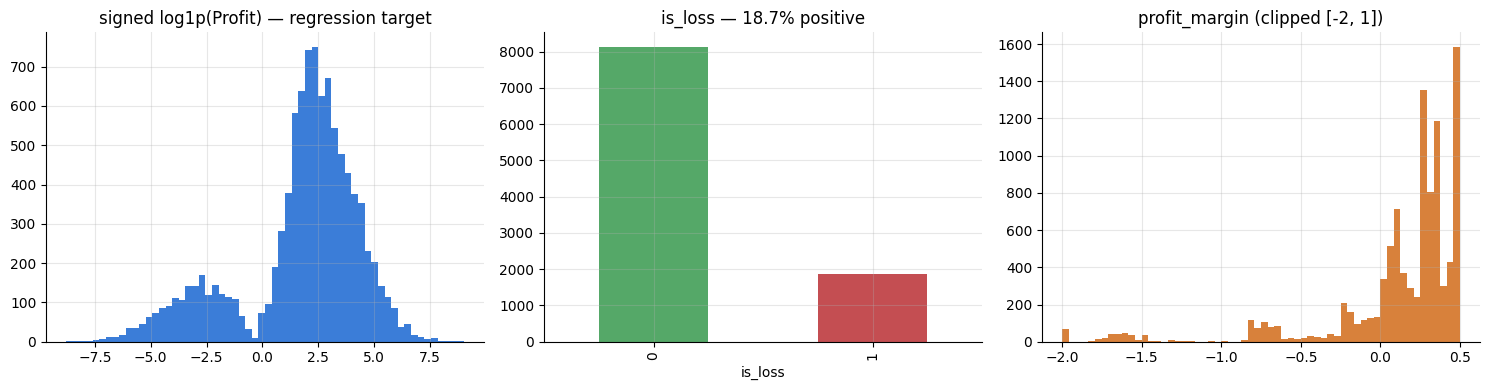

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(np.sign(feat['Profit']) * np.log1p(feat['Profit'].abs()), bins=60, color='#3b7dd8')
axes[0].set_title('signed log1p(Profit) — regression target')
feat['is_loss'].value_counts().plot(kind='bar', ax=axes[1], color=['#55a868', '#c44e52'])
axes[1].set_title(f"is_loss — {feat['is_loss'].mean():.1%} positive")
axes[2].hist(feat['profit_margin'].clip(-2, 1), bins=60, color='#d8813b')
axes[2].set_title('profit_margin (clipped [-2, 1])')
print(savefig(fig, '03_targets'))
plt.show()

## 3 · Date & cyclical features

In [5]:
date_cols = ['order_year','order_month','order_quarter','order_week','order_dayofweek',
             'order_dayofyear','order_is_weekend','order_is_month_end','order_is_quarter_end',
             'month_sin','month_cos','dow_sin','dow_cos']
feat[date_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
order_year,9994.0,2015.722233,1.123555,2014.000000,2015.000000,2.016000e+03,2017.000000,2017.000000
order_month,9994.0,7.809686,3.284654,1.000000,5.000000,9.000000e+00,11.000000,12.000000
order_quarter,9994.0,2.882329,1.058086,1.000000,2.000000,3.000000e+00,4.000000,4.000000
order_week,9994.0,31.981289,14.374936,1.000000,20.000000,3.500000e+01,45.000000,53.000000
order_dayofweek,9994.0,3.206324,2.122925,0.000000,1.000000,4.000000e+00,5.000000,6.000000
order_dayofyear,9994.0,222.058435,100.262144,1.000000,141.000000,2.455000e+02,312.000000,366.000000
order_is_weekend,9994.0,0.336702,0.472606,0.000000,0.000000,0.000000e+00,1.000000,1.000000
order_is_month_end,9994.0,0.029718,0.169816,0.000000,0.000000,0.000000e+00,0.000000,1.000000
order_is_quarter_end,9994.0,0.009706,0.098044,0.000000,0.000000,0.000000e+00,0.000000,1.000000
month_sin,9994.0,-0.170290,0.669801,-1.000000,-0.866025,-5.000000e-01,0.500000,1.000000


C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\03_cyclical_month.png


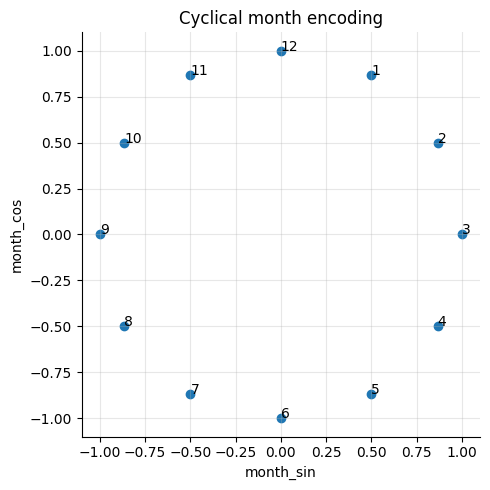

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
sub = feat.drop_duplicates('order_month')
ax.scatter(sub['month_sin'], sub['month_cos'])
for _, r in sub.iterrows():
    ax.annotate(int(r['order_month']), (r['month_sin'], r['month_cos']))
ax.set_title('Cyclical month encoding')
ax.set_xlabel('month_sin'); ax.set_ylabel('month_cos')
print(savefig(fig, '03_cyclical_month'))
plt.show()

## 4 · Line-level features

In [7]:
display(feat[['Sales','Quantity','price_per_unit','log_sales','Discount',
              'is_discounted','discount_bucket','ship_days']].head())
feat['discount_bucket'].value_counts()

,Sales,Quantity,price_per_unit,log_sales,Discount,is_discounted,discount_bucket,ship_days
0,261.9600,2,130.9800,5.572002,0.00,0,none,3
1,731.9400,3,243.9800,6.597064,0.00,0,none,3
2,14.6200,2,7.3100,2.748552,0.00,0,none,4
3,957.5775,5,191.5155,6.865450,0.45,1,high,7
4,22.3680,2,11.1840,3.151368,0.20,1,mid,7


discount_bucket
none       4798
mid        3884
extreme     856
high        310
low         146
Name: count, dtype: int64

In [8]:
bucket_stats = (feat.groupby('discount_bucket')
                    .agg(n=('Row ID','size'), avg_profit=('Profit','mean'),
                         loss_rate=('is_loss','mean'), avg_margin=('profit_margin','mean'))
                    .reindex(['none','low','mid','high','extreme']))
bucket_stats.to_csv(TABLE_DIR / '03_discount_bucket_stats.csv')
bucket_stats

,n,avg_profit,loss_rate,avg_margin
discount_bucket,,,,
none,4798,66.900292,0.000000,0.340160
low,146,71.562798,0.143836,0.112472
mid,3884,20.589091,0.182801,0.159754
high,310,-156.282991,0.916129,-0.296062
extreme,856,-89.438144,1.000000,-1.138785


## 5 · Leakage-safe customer history

Each row's customer aggregates are built from that customer's *earlier* orders only (`groupby(...).shift().expanding()`), so they are safe to use as predictors.

In [9]:
hist_cols = ['cust_prior_lines','cust_prior_sales_sum','cust_prior_sales_mean',
             'cust_prior_loss_rate','cust_days_since_first','cust_is_first_order']
feat[hist_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
cust_prior_lines,9994.0,7.345507,5.932878,0.0,3.000000,6.000000,11.000000,36.000
cust_prior_sales_sum,9994.0,1709.878099,2231.893712,0.0,253.196750,1003.358000,2294.395250,25035.082
cust_prior_sales_mean,9994.0,214.382729,320.259157,0.0,63.741659,147.984340,269.072000,11729.890
cust_prior_loss_rate,9994.0,0.173209,0.215402,0.0,0.000000,0.111111,0.285714,1.000
cust_days_since_first,9994.0,573.609866,422.573515,0.0,171.000000,572.000000,934.000000,1440.000
cust_is_first_order,9994.0,0.079348,0.270294,0.0,0.000000,0.000000,0.000000,1.000


In [10]:
# sanity: a customer's first-ever line must have zero history
first_lines = feat[feat['cust_is_first_order'] == 1]
print('first orders:', len(first_lines))
print('max prior_lines on first orders:', first_lines['cust_prior_lines'].max())
print('max prior_sales on first orders:', first_lines['cust_prior_sales_sum'].max())

first orders: 793
max prior_lines on first orders: 0
max prior_sales on first orders: 0.0


C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\03_history_vs_target.png


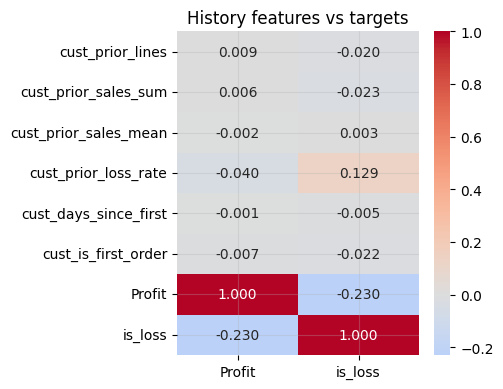

In [11]:
corr_hist = feat[hist_cols + ['Profit','is_loss']].corr()[['Profit','is_loss']]
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_hist, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('History features vs targets')
print(savefig(fig, '03_history_vs_target'))
plt.show()

## 6 · Model matrix (`make_supervised`)

In [12]:
X, y_reg, y_clf = F.make_supervised(df)
print('X:', X.shape)
print('numeric   :', len(F.NUMERIC_FEATURES))
print('categorical:', len(F.CATEGORICAL_FEATURES), '->', F.CATEGORICAL_FEATURES)
print('any nulls :', int(X.isna().sum().sum()))
X.head()

X: (9994, 32)
numeric   : 26
categorical: 6 -> ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category', 'discount_bucket']
any nulls : 0


,Sales,Quantity,Discount,ship_days,price_per_unit,log_sales,is_discounted,order_year,order_month,order_quarter,...,cust_prior_sales_mean,cust_prior_loss_rate,cust_days_since_first,cust_is_first_order,Ship Mode,Segment,Region,Category,Sub-Category,discount_bucket
0,261.9600,2,0.00,3,130.9800,5.572002,0,2016,11,4,...,68.360000,0.500000,390,0,Second Class,Consumer,South,Furniture,Bookcases,none
1,731.9400,3,0.00,3,243.9800,6.597064,0,2016,11,4,...,132.893333,0.333333,390,0,Second Class,Consumer,South,Furniture,Chairs,none
2,14.6200,2,0.00,4,7.3100,2.748552,0,2016,6,2,...,0.000000,0.000000,0,1,Second Class,Corporate,West,Office Supplies,Labels,none
3,957.5775,5,0.45,7,191.5155,6.865450,1,2015,10,4,...,0.000000,0.000000,0,1,Standard Class,Consumer,South,Furniture,Tables,high
4,22.3680,2,0.20,7,11.1840,3.151368,1,2015,10,4,...,957.577500,1.000000,0,0,Standard Class,Consumer,South,Office Supplies,Storage,mid


## 7 · RFM table

(793, 8)


,Customer ID,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
31,AH-10210,7,9,4805.3440,5,5,5,15
35,AI-10855,14,10,4375.7860,5,5,5,15
787,WB-21850,21,11,6160.1020,5,5,5,15
314,GZ-14470,8,9,4355.1500,5,5,5,15
328,HM-14860,3,10,8236.7648,5,5,5,15


C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\03_rfm_distributions.png


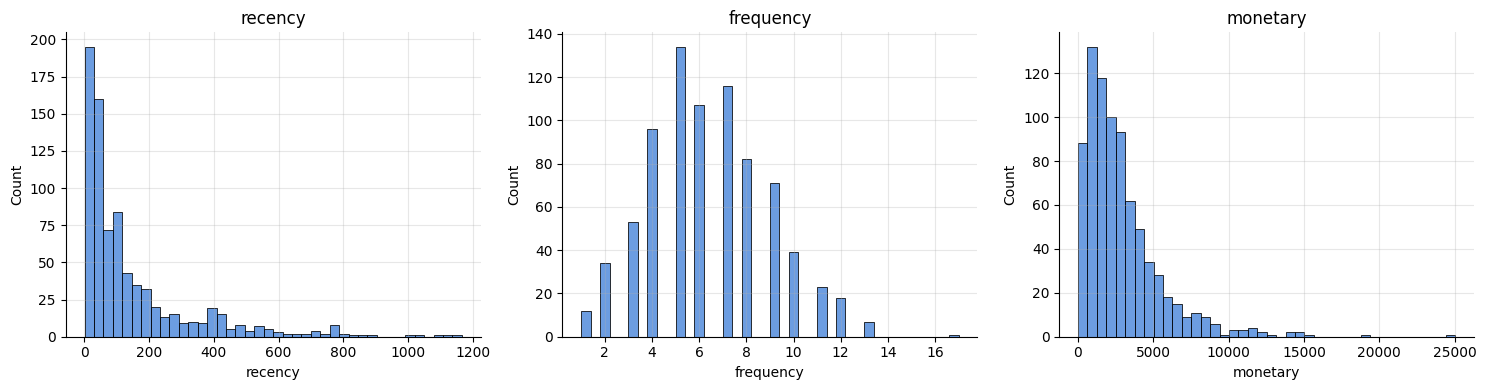

In [13]:
rfm = F.rfm_table(df)
rfm.to_csv(TABLE_DIR / '03_rfm.csv', index=False)
print(rfm.shape)
display(rfm.sort_values('rfm_score', ascending=False).head())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, ['recency', 'frequency', 'monetary']):
    sns.histplot(rfm[c], bins=40, ax=ax, color='#3b7dd8')
    ax.set_title(c)
print(savefig(fig, '03_rfm_distributions'))
plt.show()

In [14]:
seg = pd.cut(rfm['rfm_score'], [2, 6, 9, 12, 15],
             labels=['at risk', 'needs attention', 'loyal', 'champions'])
rfm.assign(segment=seg).groupby('segment', observed=True).agg(
    customers=('Customer ID', 'size'), avg_monetary=('monetary', 'mean'),
    avg_frequency=('frequency', 'mean'), avg_recency=('recency', 'mean'))

,customers,avg_monetary,avg_frequency,avg_recency
segment,,,,
at risk,196,988.887938,3.719388,329.061224
needs attention,219,2160.379412,5.579909,137.689498
loyal,254,3869.373042,7.444882,75.106299
champions,124,5221.249844,9.411290,28.064516


## 8 · Persist processed artefacts

`data_processed/` is git-ignored — downstream notebooks regenerate it by calling `src.features` directly, so results never depend on a stale file.

In [15]:
try:
    feat.to_parquet(PROCESSED_DIR / 'features_line.parquet')
    fmt = 'parquet'
except Exception as e:
    feat.to_csv(PROCESSED_DIR / 'features_line.csv', index=False)
    fmt = f'csv (parquet unavailable: {e})'
F.monthly_sales(df).to_csv(PROCESSED_DIR / 'monthly_sales.csv')
rfm.to_csv(PROCESSED_DIR / 'rfm.csv', index=False)
print('processed feature frame written as', fmt)
print('files:', [p.name for p in PROCESSED_DIR.iterdir()])

processed feature frame written as parquet
files: ['features_line.csv', 'features_line.parquet', 'monthly_sales.csv', 'rfm.csv']


## Takeaways

- 24 engineered columns on top of the raw 21; final supervised matrix is **9,994 × 32** (26 numeric + 6 categorical), zero nulls.
- `cust_prior_loss_rate` is the strongest single history signal for `is_loss`; `discount_bucket` cleanly separates profit (mean profit goes negative at `mid` and below).
- First-order sanity check passes: no leakage from a customer's own/future orders.
- RFM splits the 793 customers into champions / loyal / needs-attention / at-risk.

Next: `04_forecasting.ipynb`.